# Hafta 3: Biyolojik Dosya Formatları, SeqRecord ve SeqIO

**Biyoenformatiğe Giriş (Python & Biopython)**

**Bu haftanın hedefleri**
1. FASTA ve GenBank formatlarının yapısını tanımak.
2. `SeqRecord` nesnesinin alanlarını (id, description, annotations, features, letter_annotations) kullanmak.
3. `SeqIO.parse / read / write / convert / to_dict / index` fonksiyonlarını uygulamak.
4. GenBank özelliklerinden (feature) gen dizilerini çıkarmak ve basit bir genom haritası çizmek.

**Veri:** `ornek_genler.fasta`, `ornek_plazmit.gb` (sentetik, ders için üretilmiştir)

> **Kullanım:** Colab'da *Çalışma zamanı → Tümünü çalıştır* ile tüm hücreleri sırayla çalıştırabilirsiniz. Alıştırmaların çözümleri notebook'un sonundadır; önce kendiniz deneyin.

In [1]:
# Colab'da gerekli kütüphaneleri kur (yalnızca ilk çalıştırmada birkaç saniye sürer)
!pip -q install biopython 
import Bio
print('Biopython sürümü:', Bio.__version__)

Biopython sürümü: 1.88


In [2]:
# ---------------- VERİ SETİNİ HAZIRLA ----------------
# Veri dosyaları ders paketindeki 'veri' klasöründe de mevcuttur.
# İsterseniz Colab'ın sol panelinden 'veri' klasörü oluşturup dosyaları yükleyebilirsiniz;
# dosya bulunamazsa aşağıdaki fonksiyon(lar) AYNI veriyi (sabit tohum) yeniden üretir.
import os

def veri_uret_plazmit(klasor="veri"):
    """ornek_plazmit.gb (GenBank) ve ornek_genler.fasta dosyalarını üretir."""
    import os, random
    from Bio.Seq import Seq
    from Bio.SeqRecord import SeqRecord
    from Bio.SeqFeature import SeqFeature, FeatureLocation
    from Bio import SeqIO
    os.makedirs(klasor, exist_ok=True)
    rng = random.Random(42)
    stop = ["TAA", "TAG", "TGA"]
    anlamli = [a + b + c for a in "ACGT" for b in "ACGT" for c in "ACGT"
               if a + b + c not in stop]
    engel = ["GAATTC", "GGATCC", "AAGCTT"]          # EcoRI, BamHI, HindIII

    def rastgele(n, gc=0.5):
        w = [(1 - gc) / 2, gc / 2, gc / 2, (1 - gc) / 2]
        while True:
            s = "".join(rng.choices("ACGT", weights=w, k=n))
            if not any(e in s for e in engel):
                return s

    def orf(n_kodon, gc=0.5):
        while True:
            govde = "".join(rng.choice(anlamli) for _ in range(n_kodon - 2))
            s = "ATG" + govde + rng.choice(stop)
            if not any(e in s for e in engel):
                return s

    parcalar, ozellikler, pos = [], [], 0

    def ekle(s, tip=None, **q):
        nonlocal pos
        bas = pos
        parcalar.append(s)
        pos += len(s)
        if tip:
            ozellikler.append((tip, bas, pos, q))
        return bas, pos

    ekle(rastgele(180))
    ekle("TTGACA" + rastgele(17) + "TATAAT", "promoter", note="sigma70 benzeri promotor (-35/-10)")
    ekle(rastgele(12))
    ekle("AGGAGG", "RBS", note="Shine-Dalgarno dizisi")
    ekle(rastgele(7))
    cds1 = orf(300)
    ekle(cds1, "CDS+", gene="ornA", product="ornek protein A")
    ekle(rastgele(60))
    ekle("GAATTC", "misc_feature", note="EcoRI kesim yeri")
    ekle(rastgele(120))
    cds2 = orf(200, gc=0.45)
    ekle(str(Seq(cds2).reverse_complement()), "CDS-", gene="ornB", product="ornek protein B")
    ekle(rastgele(80))
    ekle("GGATCC", "misc_feature", note="BamHI kesim yeri")
    ekle(rastgele(150))
    ekle("AAGCTT", "misc_feature", note="HindIII kesim yeri")
    ekle(rastgele(3000 - pos - 20))
    ekle("GAATTC", "misc_feature", note="EcoRI kesim yeri (2)")
    ekle(rastgele(3000 - pos))
    dizi = "".join(parcalar)

    kayit = SeqRecord(Seq(dizi), id="pORNEK1", name="pORNEK1",
                      description="Sentetik ornek plazmit, Biyoenformatige Giris dersi")
    kayit.annotations["molecule_type"] = "DNA"
    kayit.annotations["topology"] = "circular"
    kayit.annotations["organism"] = "sentetik yapi"
    kayit.annotations["data_file_division"] = "SYN"
    kayit.annotations["date"] = "01-SEP-2026"
    kayit.features.append(SeqFeature(FeatureLocation(0, len(dizi), strand=1), type="source",
                                     qualifiers={"organism": ["sentetik yapi"], "mol_type": ["genomic DNA"]}))
    for tip, b, s, q in ozellikler:
        if tip.startswith("CDS"):
            strand = 1 if tip == "CDS+" else -1
            f = SeqFeature(FeatureLocation(b, s, strand=strand), type="CDS",
                           qualifiers={k: [v] for k, v in q.items()})
            f.qualifiers["translation"] = [str(f.extract(kayit.seq).translate(to_stop=True))]
            f.qualifiers["codon_start"] = ["1"]
            f.qualifiers["transl_table"] = ["11"]
        else:
            f = SeqFeature(FeatureLocation(b, s, strand=1), type=tip,
                           qualifiers={k: [v] for k, v in q.items()})
        kayit.features.append(f)
    SeqIO.write(kayit, os.path.join(klasor, "ornek_plazmit.gb"), "genbank")

    genler = [
        SeqRecord(Seq(cds1), id="ornA", description="plazmitteki ileri yonlu gen"),
        SeqRecord(Seq(cds2), id="ornB", description="plazmitteki ters yonlu gen (5'->3')"),
        SeqRecord(Seq(orf(150, gc=0.68)), id="yuksekGC", description="GC orani yuksek sentetik gen"),
        SeqRecord(Seq(orf(150, gc=0.32)), id="dusukGC", description="GC orani dusuk sentetik gen"),
        SeqRecord(Seq(orf(80)), id="kisaGen", description="kisa sentetik gen"),
    ]
    # GC eğilimli genleri kodon seçimiyle üret
    def gc_orf(n, gc):
        agirlik = []
        for k in anlamli:
            g = sum(c in "GC" for c in k)
            agirlik.append((gc / 0.5) ** g * ((1 - gc) / 0.5) ** (3 - g))
        while True:
            s = "ATG" + "".join(rng.choices(anlamli, weights=agirlik, k=n - 2)) + "TAA"
            if not any(e in s for e in engel):
                return s
    genler[2].seq = Seq(gc_orf(150, 0.68))
    genler[3].seq = Seq(gc_orf(150, 0.32))
    SeqIO.write(genler, os.path.join(klasor, "ornek_genler.fasta"), "fasta")


if not os.path.exists('veri/ornek_plazmit.gb'):
    veri_uret_plazmit()
print('veri klasörü:', sorted(os.listdir('veri')))


veri klasörü: ['1A8O.pdb', 'ornek_genler.fasta', 'ornek_plazmit.gb']


## 1. FASTA formatı
```
>kimlik açıklama metni          <- başlık satırı ('>' ile başlar)
ATGCGTACGTTAGC...               <- dizi (genelde 60-80 karakterlik satırlar)
>ikinci_kayit ...
...
```
| Özellik | FASTA | GenBank | FASTQ |
|---|---|---|---|
| İçerik | Dizi + başlık | Dizi + zengin açıklama + özellikler | Dizi + baz kalite skoru |
| Kullanım | Veritabanı, hizalama girdisi | Gen/genom arşivi | Yeni nesil dizileme okumaları |
| Biopython format adı | `"fasta"` | `"genbank"` / `"gb"` | `"fastq"` |

In [3]:
print(open("veri/ornek_genler.fasta").read()[:600])

>ornA plazmitteki ileri yonlu gen
ATGATATCTAACGCTAGCATTAGACTGGGGACTGCATTTATCCTCGTACAATATCCTAGG
GCGGCGGTTGTCACTTATTCGAGGCATACGGCCAACTTGCATGCAGGTTTCCGACGCTTT
GTCATAACAGCCGTATCTGGAATTACGGTATATCATTGCGGTGCGTCCACTTCAGCATCA
AAGCCGGAGCGTGGGCCTACAGAAGGCCCCAAATGCCGGTCGCTTACGCGTCCTGGATTA
TCTCTCGTCAGCCGTAGTGTGGACGGCCACGCTTCCTTCGAGTATCTGCTCCGTTCGGTG
GCCCACCCATGCATTTCTTTGACCCACTGTCTAATTTACCTCGCAGCTGGGCGACCCAAC
CTTTGCCCAAGTCTTATCCCGTCCCAACCCCACTGTGCGGTATGTCACGATAAAGACTTT
ATAACCATTGTGCGGCTTGATTACATTGTACTGGGCGTCCTTCTATCAAACACCCAGATG
CGCGTAATTCATGGGGCCCCTCTGGATGACCCGCGTGTTGATCCCCCGGTACTCCACCAT
CAAATGACTGTGATACC


In [4]:
from Bio import SeqIO

for kayit in SeqIO.parse("veri/ornek_genler.fasta", "fasta"):
    print(f"{kayit.id:10s} uzunluk={len(kayit):4d}  açıklama='{kayit.description}'")

ornA       uzunluk= 900  açıklama='ornA plazmitteki ileri yonlu gen'
ornB       uzunluk= 600  açıklama='ornB plazmitteki ters yonlu gen (5'->3')'
yuksekGC   uzunluk= 450  açıklama='yuksekGC GC orani yuksek sentetik gen'
dusukGC    uzunluk= 450  açıklama='dusukGC GC orani dusuk sentetik gen'
kisaGen    uzunluk= 240  açıklama='kisaGen kisa sentetik gen'


## 2. `SeqRecord` nesnesi

| Alan | Açıklama |
|---|---|
| `.seq` | `Seq` nesnesi |
| `.id`, `.name`, `.description` | Tanımlayıcılar |
| `.annotations` | Kayıt düzeyinde sözlük (organizma, tarih, molekül tipi...) |
| `.features` | `SeqFeature` listesi (gen, CDS, promotör...) |
| `.letter_annotations` | Her harf için bir değer (ör. FASTQ kalite skorları) |
| `.dbxrefs` | Diğer veritabanlarına bağlantılar |

In [5]:
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

yeni = SeqRecord(Seq("ATGGCGTAA"), id="deneme1", description="elle oluşturulan kayıt")
yeni.annotations["molecule_type"] = "DNA"
print(yeni)
print()
print(yeni.format("fasta"))

ID: deneme1
Name: <unknown name>
Description: elle oluşturulan kayıt
Number of features: 0
/molecule_type=DNA
Seq('ATGGCGTAA')

>deneme1 elle oluşturulan kayıt
ATGGCGTAA



## 3. Okuma yöntemleri: hangisi ne zaman?

| Fonksiyon | Döndürdüğü | Bellek | Ne zaman? |
|---|---|---|---|
| `SeqIO.parse()` | Yineleyici (iterator) | Düşük | Büyük dosyaları sırayla işlemek |
| `SeqIO.read()` | Tek `SeqRecord` | — | Dosyada tam 1 kayıt varsa |
| `SeqIO.to_dict()` | `dict` | Yüksek (hepsi bellekte) | Küçük dosyada id ile erişim |
| `SeqIO.index()` | Sözlük benzeri, disk üzerinde | Düşük | Büyük dosyada rastgele erişim |

In [6]:
sozluk = SeqIO.to_dict(SeqIO.parse("veri/ornek_genler.fasta", "fasta"))
print("Anahtarlar:", list(sozluk))
print("yuksekGC ilk 60 baz:", sozluk["yuksekGC"].seq[:60])

indeks = SeqIO.index("veri/ornek_genler.fasta", "fasta")
print("index ile:", indeks["kisaGen"].id, len(indeks["kisaGen"]))
indeks.close()

# Liste kavrayışı ile filtreleme ve özet tablo
import pandas as pd
from Bio.SeqUtils import gc_fraction
tablo = pd.DataFrame([{"id": r.id, "uzunluk": len(r), "GC": round(gc_fraction(r.seq), 3),
                       "protein_uzunlugu": len(r.seq.translate(to_stop=True))}
                      for r in SeqIO.parse("veri/ornek_genler.fasta", "fasta")])
tablo

Anahtarlar: ['ornA', 'ornB', 'yuksekGC', 'dusukGC', 'kisaGen']
yuksekGC ilk 60 baz: ATGGTCCGCGTCACCGGCGAGTTGAGCGTCGGGCCGTTTCGTCGAGTCCGTTTGGGGCCA
index ile: kisaGen 240


,id,uzunluk,GC,protein_uzunlugu
0,ornA,900,0.502,299
1,ornB,600,0.547,199
2,yuksekGC,450,0.669,149
3,dusukGC,450,0.322,149
4,kisaGen,240,0.479,79


## 4. Yazma ve format dönüştürme

In [7]:
# 400 bazdan uzun genleri ayrı bir dosyaya yaz
uzunlar = (r for r in SeqIO.parse("veri/ornek_genler.fasta", "fasta") if len(r) > 400)
n = SeqIO.write(uzunlar, "uzun_genler.fasta", "fasta")
print(n, "kayıt yazıldı")

# Proteinlere çevirip yeni bir FASTA oluştur
proteinler = [SeqRecord(r.seq.translate(to_stop=True), id=r.id + "_prot", description="çeviri")
              for r in SeqIO.parse("veri/ornek_genler.fasta", "fasta")]
SeqIO.write(proteinler, "proteinler.fasta", "fasta")
print(open("proteinler.fasta").read()[:300])

# GenBank -> FASTA dönüşümü tek satırda
print(SeqIO.convert("veri/ornek_plazmit.gb", "genbank", "plazmit.fasta", "fasta"), "kayıt dönüştürüldü")

4 kayıt yazıldı
>ornA_prot çeviri
MISNASIRLGTAFILVQYPRAAVVTYSRHTANLHAGFRRFVITAVSGITVYHCGASTSAS
KPERGPTEGPKCRSLTRPGLSLVSRSVDGHASFEYLLRSVAHPCISLTHCLIYLAAGRPN
LCPSLIPSQPHCAVCHDKDFITIVRLDYIVLGVLLSNTQMRVIHGAPLDDPRVDPPVLHH
QMTVIPTVEFYVSIIVLHVAYDAQTSIQMPSHKVERHKNDQVFRGWYLTWKAQLLLPSNQ
FWLTSTRLTAGGNSSSAFHTITDYRAASAMYDRLFLHW
1 kayıt dönüştürüldü


## 5. GenBank formatı
GenBank dosyası üç bölümden oluşur: **başlık** (LOCUS, DEFINITION, ...), **FEATURES** tablosu ve **ORIGIN** (dizi).

In [8]:
print(open("veri/ornek_plazmit.gb").read()[:1800])

LOCUS       pORNEK1                 3000 bp    DNA     circular SYN 01-SEP-2026
DEFINITION  Sentetik ornek plazmit, Biyoenformatige Giris dersi.
ACCESSION   pORNEK1
VERSION     pORNEK1
KEYWORDS    .
SOURCE      .
  ORGANISM  sentetik yapi
            .
FEATURES             Location/Qualifiers
     source          1..3000
                     /organism="sentetik yapi"
                     /mol_type="genomic DNA"
     promoter        181..209
                     /note="sigma70 benzeri promotor (-35/-10)"
     RBS             222..227
                     /note="Shine-Dalgarno dizisi"
     CDS             235..1134
                     /gene="ornA"
                     /product="ornek protein A"
                     /translation="MISNASIRLGTAFILVQYPRAAVVTYSRHTANLHAGFRRFVITAV
                     SGITVYHCGASTSASKPERGPTEGPKCRSLTRPGLSLVSRSVDGHASFEYLLRSVAHPC
                     ISLTHCLIYLAAGRPNLCPSLIPSQPHCAVCHDKDFITIVRLDYIVLGVLLSNTQMRVI
                     HGAPLDDPRVDPPVLHHQMTVIPTVEFYVSIIV

In [9]:
plazmit = SeqIO.read("veri/ornek_plazmit.gb", "genbank")
print("ID:", plazmit.id, "| uzunluk:", len(plazmit))
print("Açıklamalar:")
for k, v in plazmit.annotations.items():
    print(f"   {k}: {v}")
print("\nÖzellik sayısı:", len(plazmit.features))
for f in plazmit.features:
    etiket = f.qualifiers.get("gene", f.qualifiers.get("note", [""]))[0]
    print(f"  {f.type:13s} {str(f.location):22s} {etiket}")

ID: pORNEK1 | uzunluk: 3000
Açıklamalar:
   molecule_type: DNA
   topology: circular
   data_file_division: SYN
   date: 01-SEP-2026
   accessions: ['pORNEK1']
   keywords: ['']
   source: 
   organism: sentetik yapi
   taxonomy: []

Özellik sayısı: 9
  source        [0:3000](+)            
  promoter      [180:209](+)           sigma70 benzeri promotor (-35/-10)
  RBS           [221:227](+)           Shine-Dalgarno dizisi
  CDS           [234:1134](+)          ornA
  misc_feature  [1194:1200](+)         EcoRI kesim yeri
  CDS           [1320:1920](-)         ornB
  misc_feature  [2000:2006](+)         BamHI kesim yeri
  misc_feature  [2156:2162](+)         HindIII kesim yeri
  misc_feature  [2980:2986](+)         EcoRI kesim yeri (2)


### Konum (location) gösterimi — sık yapılan hata!
Biopython **0 tabanlı, yarı açık** aralık kullanır: `[180:209]` → 181..209 (GenBank'te 1 tabanlı, kapalı).

| Gösterim | Başlangıç | Bitiş | Uzunluk |
|---|---|---|---|
| GenBank `181..209` | 181 (1-tabanlı) | 209 (dahil) | 29 |
| Biopython `[180:209]` | 180 (0-tabanlı) | 209 (hariç) | 209 − 180 = 29 |

In [10]:
for f in plazmit.features:
    if f.type == "CDS":
        gen_dizisi = f.extract(plazmit.seq)            # ters iplikte ise ters tamamlayıcıyı otomatik alır
        protein = gen_dizisi.translate(table=11, cds=True)
        kayitli = f.qualifiers["translation"][0]
        print(f"{f.qualifiers['gene'][0]}: iplik={f.location.strand:+d}, {len(gen_dizisi)} bp, "
              f"{len(protein)} aa, açıklamadaki çeviriyle aynı mı? {str(protein) == kayitli}")
        print("   ilk 40 aa:", protein[:40])

ornA: iplik=+1, 900 bp, 299 aa, açıklamadaki çeviriyle aynı mı? True
   ilk 40 aa: MISNASIRLGTAFILVQYPRAAVVTYSRHTANLHAGFRRF
ornB: iplik=-1, 600 bp, 199 aa, açıklamadaki çeviriyle aynı mı? True
   ilk 40 aa: MPSGLLTTSTTRTVVPSRDNADDPGTRPWGFYRWFVNQAH


## 6. Basit bir genom/plazmit haritası

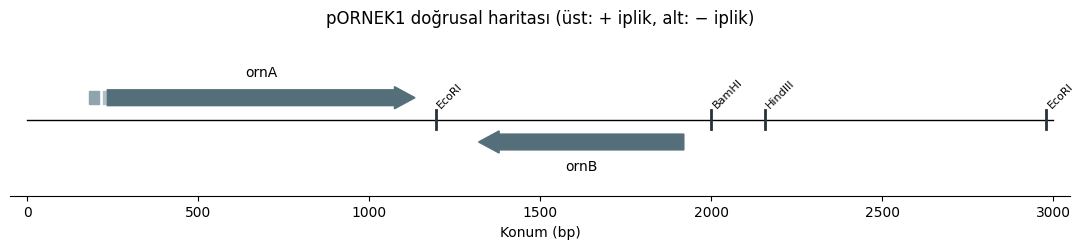

In [11]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow

renk = {"CDS": "#546e7a", "promoter": "#90a4ae", "RBS": "#b0bec5", "misc_feature": "#263238"}
fig, ax = plt.subplots(figsize=(11, 2.6))
ax.plot([0, len(plazmit)], [0, 0], color="black", lw=1)
for f in plazmit.features:
    if f.type == "source":
        continue
    b, s = int(f.location.start), int(f.location.end)
    y = 0.35 if f.location.strand == 1 else -0.35
    if f.type == "CDS":
        bas, uz = (b, s - b) if f.location.strand == 1 else (s, -(s - b))
        ax.add_patch(FancyArrow(bas, y, uz, 0, width=0.25, head_width=0.35,
                                head_length=60, length_includes_head=True, color=renk["CDS"]))
        ax.text((b + s) / 2, y + (0.35 if y > 0 else -0.45), f.qualifiers["gene"][0], ha="center")
    elif f.type == "misc_feature":
        ax.plot([b, b], [-0.15, 0.15], color=renk[f.type], lw=2)
        ax.text(b, 0.2, f.qualifiers["note"][0].split()[0], rotation=45, fontsize=8)
    else:
        ax.add_patch(plt.Rectangle((b, y - 0.1), s - b, 0.2, color=renk[f.type]))
ax.set_ylim(-1.2, 1.4); ax.set_xlim(-50, len(plazmit) + 50)
ax.set_yticks([]); ax.set_xlabel("Konum (bp)"); ax.set_title("pORNEK1 doğrusal haritası (üst: + iplik, alt: − iplik)")
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

## 7. (İsteğe bağlı, internet gerekir) NCBI'dan GenBank kaydı indirmek
`Bio.Entrez` ile NCBI'dan kayıt çekilebilir. NCBI e-posta adresi ister. Ayrıntılar 8. haftada.

In [12]:
from Bio import Entrez
Entrez.email = "ogrenci@ornek.edu.tr"      # kendi e-posta adresinizi yazın

try:
    with Entrez.efetch(db="nucleotide", id="NC_001422.1", rettype="gb", retmode="text") as h:
        phix = SeqIO.read(h, "genbank")
    print(phix.description, "|", len(phix), "bp |", sum(f.type == "CDS" for f in phix.features), "CDS")
except Exception as e:
    print("NCBI'ya erişilemedi (çevrimdışı olabilirsiniz):", type(e).__name__)

NCBI'ya erişilemedi (çevrimdışı olabilirsiniz): URLError


## 8. Alıştırmalar
1. `ornek_genler.fasta` dosyasındaki her kaydın ilk 30 bazını ve GC oranını yazdırın; GC oranına göre büyükten küçüğe sıralayın.
2. Plazmitteki tüm özelliklerin (source hariç) türünü, başlangıç–bitiş konumunu (**1 tabanlı**) ve uzunluğunu içeren bir `pandas` tablosu oluşturup CSV olarak kaydedin.
3. `ornB` geninin dizisini (a) `feature.extract` ile, (b) elle dilimleyip ters tamamlayıcı alarak elde edin ve eşit olduklarını gösterin.
4. `SeqIO.write` ile, plazmitin sadece CDS'lerinin protein dizilerini içeren bir FASTA dosyası yazın. Başlıkta gen adı ve protein uzunluğu olsun.

---
## Çözümler

In [13]:
# 1
kayitlar = sorted(SeqIO.parse("veri/ornek_genler.fasta", "fasta"), key=lambda r: gc_fraction(r.seq), reverse=True)
for r in kayitlar:
    print(f"1) {r.id:9s} {r.seq[:30]}  GC={gc_fraction(r.seq):.3f}")

# 2
satirlar = [{"tur": f.type, "bas_1tabanli": int(f.location.start) + 1, "bitis": int(f.location.end),
             "uzunluk": len(f), "iplik": f.location.strand}
            for f in plazmit.features if f.type != "source"]
df = pd.DataFrame(satirlar); df.to_csv("plazmit_ozellikleri.csv", index=False)
print(df)

# 3
f = [f for f in plazmit.features if f.qualifiers.get("gene") == ["ornB"]][0]
a = f.extract(plazmit.seq)
b = plazmit.seq[int(f.location.start):int(f.location.end)].reverse_complement()
print("3) eşit mi?", a == b)

# 4
prots = []
for f in plazmit.features:
    if f.type == "CDS":
        p = f.extract(plazmit.seq).translate(table=11, to_stop=True)
        prots.append(SeqRecord(p, id=f.qualifiers["gene"][0], description=f"uzunluk={len(p)} aa"))
SeqIO.write(prots, "plazmit_proteinleri.fasta", "fasta")
print(open("plazmit_proteinleri.fasta").read()[:200])

1) yuksekGC  ATGGTCCGCGTCACCGGCGAGTTGAGCGTC  GC=0.669
1) ornB      ATGCCTAGCGGTTTGCTGACAACCTCTACC  GC=0.547
1) ornA      ATGATATCTAACGCTAGCATTAGACTGGGG  GC=0.502
1) kisaGen   ATGGTAAGCGAACGACGGGCGAGAGCACGA  GC=0.479
1) dusukGC   ATGTCTTTAAACTTTAGGTGGTCCATTTGC  GC=0.322
            tur  bas_1tabanli  bitis  uzunluk  iplik
0      promoter           181    209       29      1
1           RBS           222    227        6      1
2           CDS           235   1134      900      1
3  misc_feature          1195   1200        6      1
4           CDS          1321   1920      600     -1
5  misc_feature          2001   2006        6      1
6  misc_feature          2157   2162        6      1
7  misc_feature          2981   2986        6      1
3) eşit mi? True
>ornA uzunluk=299 aa
MISNASIRLGTAFILVQYPRAAVVTYSRHTANLHAGFRRFVITAVSGITVYHCGASTSAS
KPERGPTEGPKCRSLTRPGLSLVSRSVDGHASFEYLLRSVAHPCISLTHCLIYLAAGRPN
LCPSLIPSQPHCAVCHDKDFITIVRLDYIVLGVLLSNTQMRVIHGAPLDDPRVDPPV
